# EDA — Análise Exploratória para Inferência Causal

Objetivo: mapear **todas as variáveis disponíveis** no dataset Olist para decidir quais usar como:
- **Tratamento (T)**: variável de intervenção (o que a operação pode mudar)
- **Outcome (Y)**: resultado que queremos impactar
- **Confundidores (X)**: variáveis que afetam tanto T quanto Y e precisam ser controladas

## Fontes de dados

| Arquivo | Descrição |
|---|---|
| `olist_orders_dataset` | Pedidos, status, datas do ciclo de vida |
| `olist_customers_dataset` | Dados do cliente (estado, CEP) |
| `olist_geolocation_dataset` | Coordenadas por CEP |
| `olist_order_items_dataset` | Itens, preços, fretes por pedido |
| `olist_products_dataset` | Peso, dimensões, categoria dos produtos |
| `olist_order_payments_dataset` | Pagamentos, parcelas, tipo |
| `olist_order_reviews_dataset` | contém review_score (1-5) |
| `olist_sellers_dataset` | — dados do vendedor |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from app.config.settings import INTERIM_DATA_DIR, RAW_DATA_DIR

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Dataset  — visão geral

In [2]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, "interim_dataset.parquet"))

print(f"Shape: {df.shape[0]:,} pedidos × {df.shape[1]} colunas")
print(f"\nStatus dos pedidos:")
print(df['order_status'].value_counts())

Shape: 97,712 pedidos × 37 colunas

Status dos pedidos:
order_status
delivered      96478
canceled         625
unavailable      609
Name: count, dtype: int64


In [3]:
# Mapa completo de variáveis: tipo, nulos, cardinalidade
mapa = pd.DataFrame({
    'tipo': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2),
    'únicos': df.nunique(),
    'exemplo': df.iloc[0]
})

print(mapa.to_string())

                                         tipo  nulos  nulos_%  únicos                           exemplo
order_id                                  str      0   0.0000   97712  e481f51cbdc54678b7cc49136f2d6af7
customer_id                               str      0   0.0000   97712  9ef432eb6251297304e76186b10a928d
order_status                              str      0   0.0000       3                         delivered
order_purchase_timestamp       datetime64[us]      0   0.0000   97176               2017-10-02 10:56:33
order_approved_at                         str    155   0.1600   89251               2017-10-02 11:07:15
order_delivered_carrier_date              str   1161   1.1900   80173               2017-10-04 19:55:00
order_delivered_customer_date  datetime64[us]   1236   1.2600   95664               2017-10-10 21:25:13
order_estimated_delivery_date  datetime64[us]      0   0.0000     457               2017-10-18 00:00:00
customer_unique_id                        str      0   0.0000   

## 2. Variáveis derivadas do ciclo de vida do pedido

O ciclo temporal do pedido na Olist:

```
Compra → Aprovação → Despacho (carrier) → Entrega ao cliente
```



In [4]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Intervalos operacionais
df["approval_time_hours"]  = (df["order_approved_at"] - df["order_purchase_timestamp"]).dt.total_seconds() / 3600
df["dispatch_time_days"]   = (df["order_delivered_carrier_date"] - df["order_approved_at"]).dt.days
df["delivery_time_days"]   = (df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]).dt.days
df["estimated_window_days"]= (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days
df["delay_days"]           = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
df["total_cycle_days"]     = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
df["perc_freight"]         = df["total_freight"] / df["total_price"]

intervalos = ["approval_time_hours", "dispatch_time_days", "delivery_time_days",
              "estimated_window_days", "delay_days", "total_cycle_days", "perc_freight"]

print("Estatísticas dos intervalos operacionais:")
print(df[intervalos].describe().round(2).to_string())

Estatísticas dos intervalos operacionais:
       approval_time_hours  dispatch_time_days  delivery_time_days  estimated_window_days  delay_days  total_cycle_days  perc_freight
count           97557.0000          96537.0000          96475.0000             97712.0000  96476.0000        96476.0000    96945.0000
mean               10.3900              2.3000              8.8800                23.3600    -11.8800           12.0900        0.3100
std                25.5500              3.5500              8.7500                 8.7900     10.1800            9.5500        0.3100
min                 0.0000           -172.0000            -17.0000                 1.0000   -147.0000            0.0000        0.0000
25%                 0.2200              0.0000              4.0000                18.0000    -17.0000            6.0000        0.1300
50%                 0.3400              1.0000              7.0000                23.0000    -12.0000           10.0000        0.2200
75%                1

## 2.1 Análise Descritiva das Variáveis Principais

Estatísticas descritivas das variáveis contínuas agrupadas por domínio:
- **Financeiro:** valor do pedido, frete e participação do frete
- **Logístico:** tempos de aprovação, despacho, entrega e ciclo total
- **Pedido:** número de itens e peso médio

A tabela apresenta média, desvio-padrão, mediana e intervalo interquartil (IQR), calculados sobre os pedidos com status *delivered* para evitar viés de pedidos incompletos.

In [ ]:
df_delivered = df[df['order_status'] == 'delivered'].copy()

dominios = {
    'Financeiro': ['total_price', 'total_freight', 'perc_freight'],
    'Logístico':  ['approval_time_hours', 'dispatch_time_days',
                   'delivery_time_days', 'total_cycle_days'],
    'Pedido':     ['n_items', 'avg_weight'],
}

rows = []
for dominio, cols in dominios.items():
    for col in cols:
        s = df_delivered[col].dropna()
        rows.append({
            'Domínio':   dominio,
            'Variável':  col,
            'N':         f'{len(s):,}',
            'Média':     round(s.mean(), 2),
            'DP':        round(s.std(), 2),
            'Mediana':   round(s.median(), 2),
            'IQR':       round(s.quantile(0.75) - s.quantile(0.25), 2),
            'Mín':       round(s.min(), 2),
            'Máx':       round(s.max(), 2),
        })

df_desc = pd.DataFrame(rows).set_index(['Domínio', 'Variável'])
print(df_desc.to_string())

## 3. Distribuição das variáveis numéricas contínuas

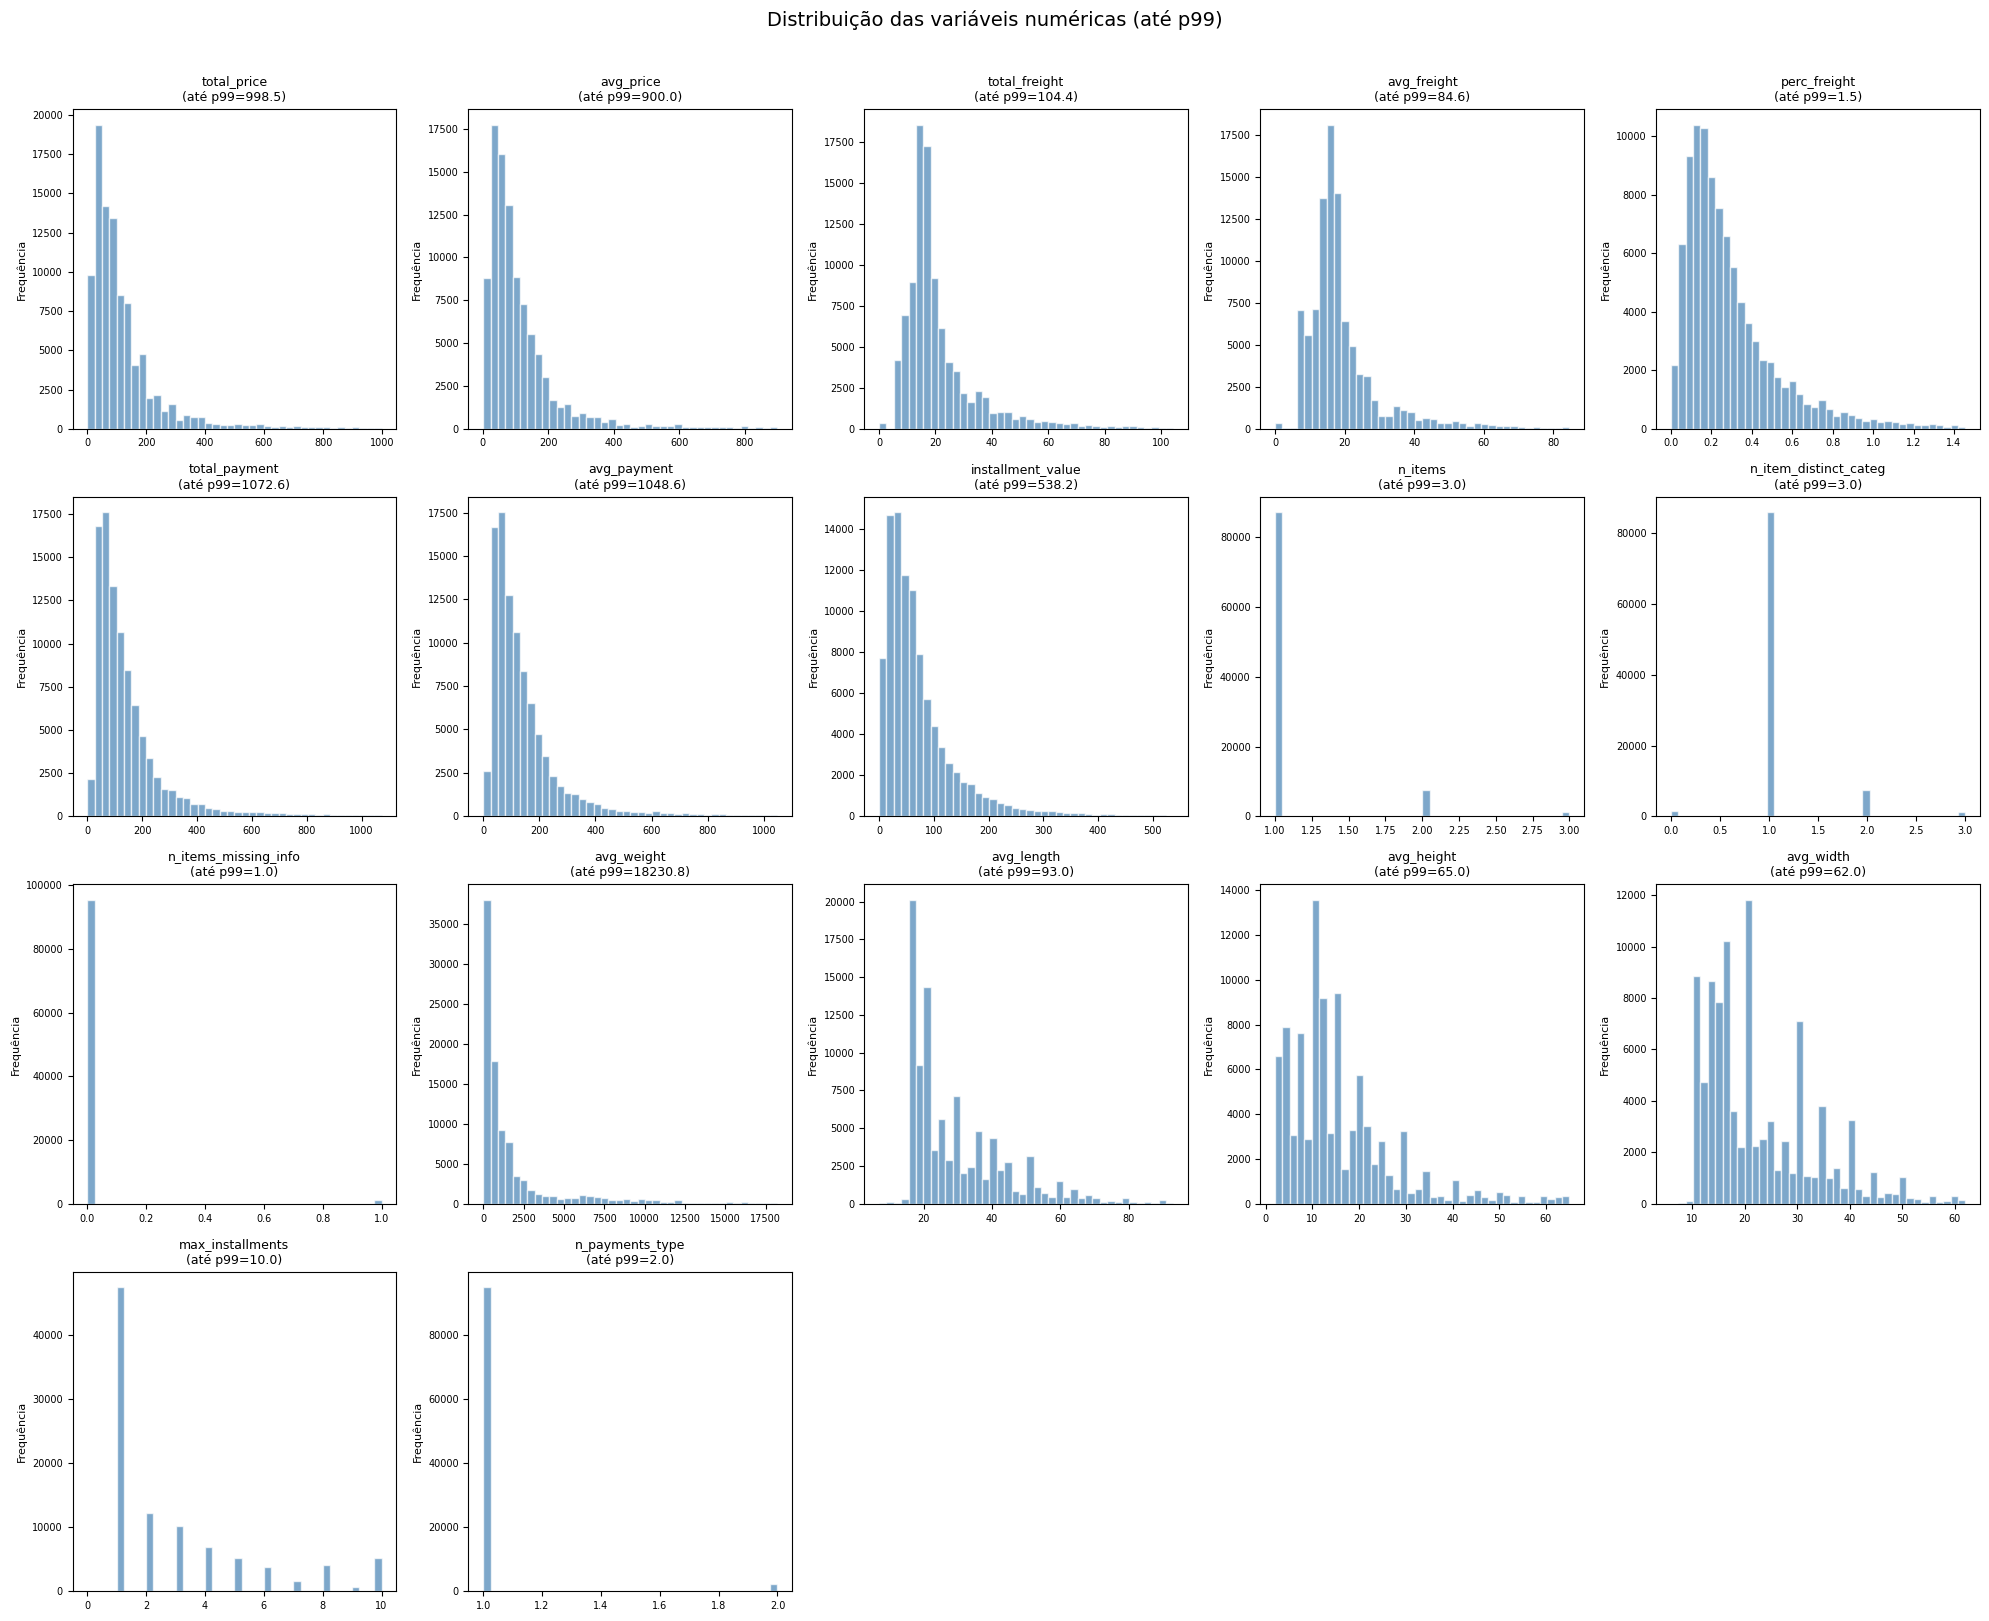

In [5]:
numericas = [
    "total_price", "avg_price", "total_freight", "avg_freight", "perc_freight",
    "total_payment", "avg_payment", "installment_value",
    "n_items", "n_item_distinct_categ", "n_items_missing_info",
    "avg_weight", "avg_length", "avg_height", "avg_width",
    "max_installments", "n_payments_type"
]

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(numericas):
    data = df[col].dropna()
    # Remove outliers extremos para visualização (percentil 99)
    p99 = data.quantile(0.99)
    data_plot = data[data <= p99]
    axes[i].hist(data_plot, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].set_title(f'{col}\n(até p99={p99:.1f})', fontsize=9)
    axes[i].set_ylabel('Frequência', fontsize=8)
    axes[i].tick_params(labelsize=7)

# Esconder os eixos extras
for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das variáveis numéricas (até p99)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/eda_numericas.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Distribuição dos intervalos operacionais (candidatos a tratamento)

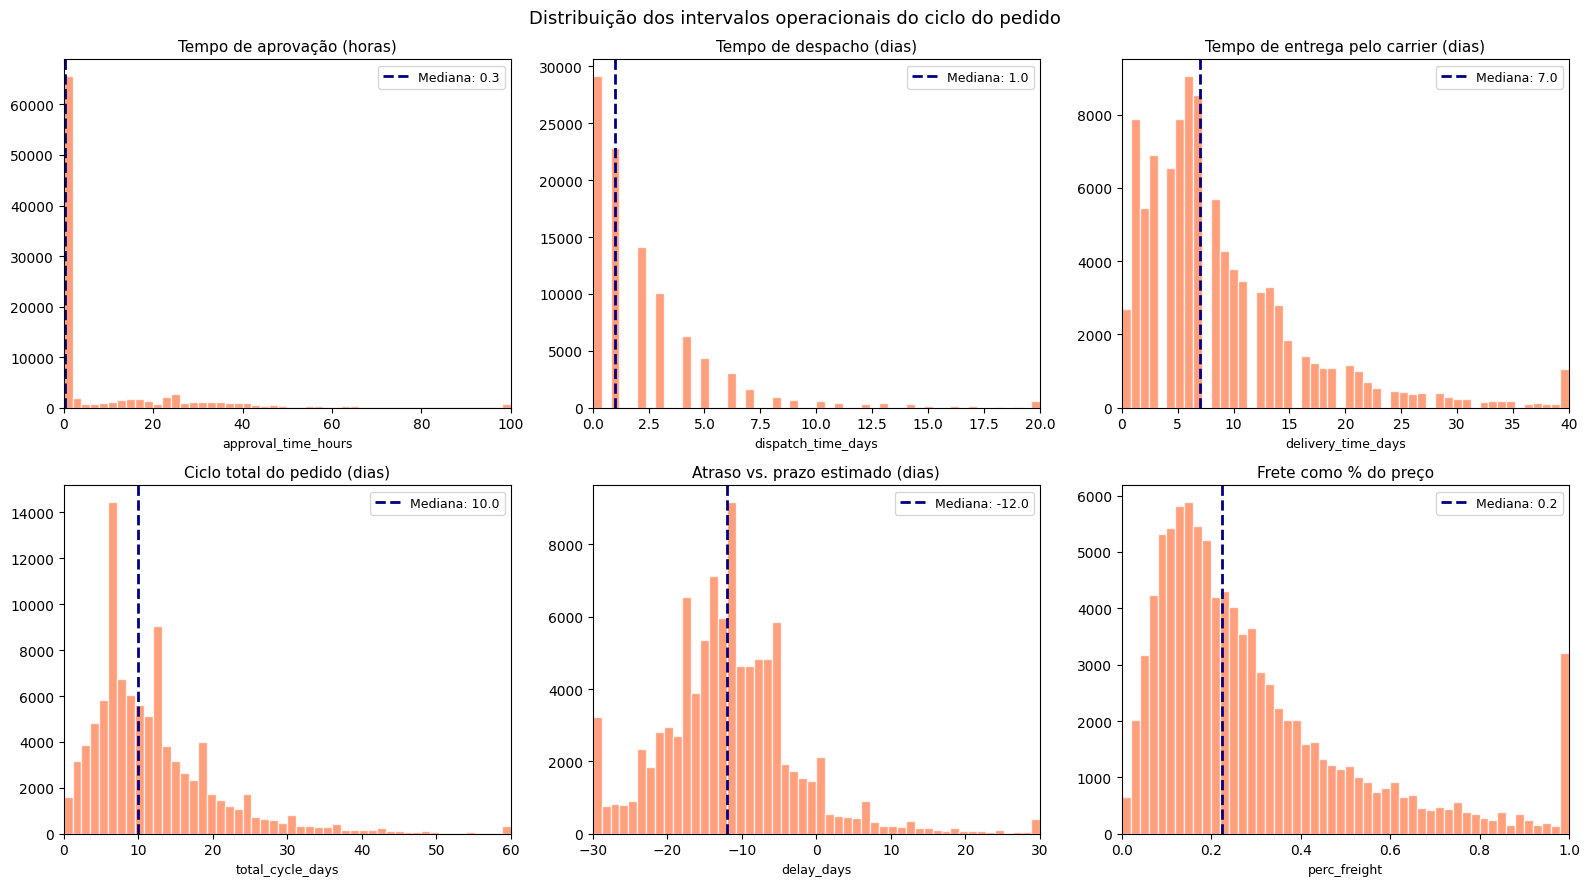

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

configs = [
    ("approval_time_hours",  (0, 100),  "Tempo de aprovação (horas)"),
    ("dispatch_time_days",   (0, 20),   "Tempo de despacho (dias)"),
    ("delivery_time_days",   (0, 40),   "Tempo de entrega pelo carrier (dias)"),
    ("total_cycle_days",     (0, 60),   "Ciclo total do pedido (dias)"),
    ("delay_days",           (-30, 30), "Atraso vs. prazo estimado (dias)"),
    ("perc_freight",         (0, 1),    "Frete como % do preço"),
]

for i, (col, xlim, titulo) in enumerate(configs):
    data = df[col].dropna()
    data_clip = data.clip(*xlim)
    axes[i].hist(data_clip, bins=50, color='coral', alpha=0.75, edgecolor='white')
    axes[i].axvline(data.median(), color='navy', linewidth=2, linestyle='--',
                    label=f'Mediana: {data.median():.1f}')
    axes[i].set_title(titulo, fontsize=11)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].legend(fontsize=9)
    axes[i].set_xlim(xlim)

plt.suptitle('Distribuição dos intervalos operacionais do ciclo do pedido', fontsize=13)
plt.tight_layout()
plt.savefig('../../reports/figures/eda_intervalos_operacionais.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Variáveis categóricas e temporais

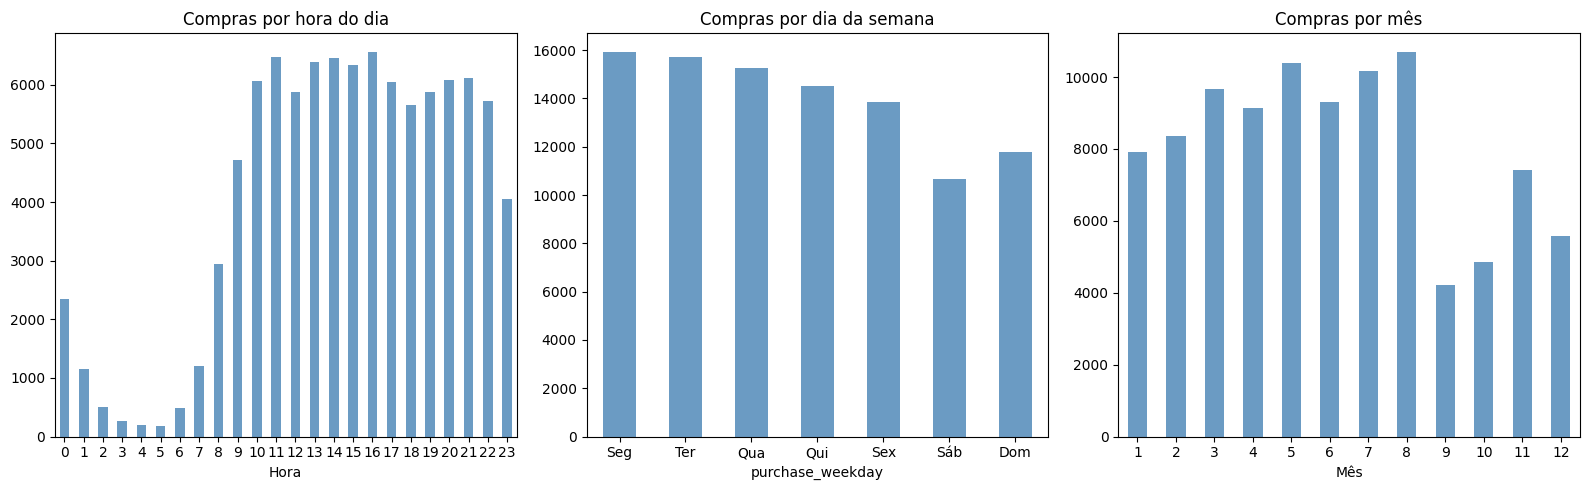

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Hora da compra
df['purchase_hour'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color='steelblue', alpha=0.8)
axes[0].set_title('Compras por hora do dia')
axes[0].set_xlabel('Hora')
axes[0].tick_params(axis='x', rotation=0)

# Dia da semana
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
df['purchase_weekday'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color='steelblue', alpha=0.8)
axes[1].set_title('Compras por dia da semana')
axes[1].set_xticklabels(dias, rotation=0)

# Mês
df['purchase_month'].value_counts().sort_index().plot(kind='bar', ax=axes[2],
    color='steelblue', alpha=0.8)
axes[2].set_title('Compras por mês')
axes[2].set_xlabel('Mês')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../../reports/figures/eda_temporais.png', dpi=120)
plt.show()

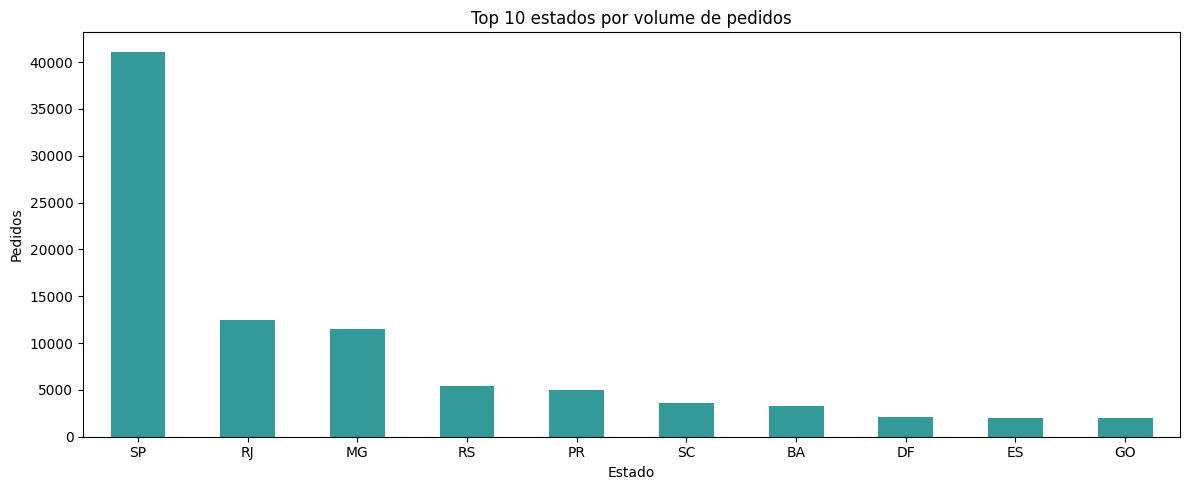


Total de estados únicos: 27
customer_state
SP    41120
RJ    12504
MG    11493
RS     5394
PR     4985
SC     3583
BA     3292
DF     2099
ES     2010
GO     1979
PE     1602
CE     1292
PA      952
MT      891
MA      728
MS      708
PB      522
PI      481
RN      477
AL      399
SE      340
TO      276
RO      250
AM      146
AC       80
AP       67
RR       42


In [8]:
# Top 10 estados
fig, ax = plt.subplots(figsize=(12, 5))
df['customer_state'].value_counts().head(10).plot(kind='bar', ax=ax,
    color='teal', alpha=0.8)
ax.set_title('Top 10 estados por volume de pedidos')
ax.set_xlabel('Estado')
ax.set_ylabel('Pedidos')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/eda_estados.png', dpi=120)
plt.show()

print(f"\nTotal de estados únicos: {df['customer_state'].nunique()}")
print(df['customer_state'].value_counts().to_string())

## 6. Dataset de reviews — 

O `olist_order_reviews_dataset` contém `review_score` (1 a 5 estrelas), que é o **julgamento direto do cliente** sobre a experiência de compra.



In [9]:
reviews_path = os.path.join(RAW_DATA_DIR, "olist_order_reviews_dataset.csv")
reviews = pd.read_csv(reviews_path)

print(f"Reviews shape: {reviews.shape}")
print(f"\nColunas: {list(reviews.columns)}")
print(f"\nDistribuição do review_score:")
print(reviews['review_score'].value_counts().sort_index())
print(f"\nPercentual:")
print((reviews['review_score'].value_counts(normalize=True).sort_index() * 100).round(2))

Reviews shape: (99224, 7)

Colunas: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Distribuição do review_score:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

Percentual:
review_score
1   11.5100
2    3.1800
3    8.2400
4   19.2900
5   57.7800
Name: proportion, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do review_score
counts = reviews['review_score'].value_counts().sort_index()
cores = ['#d32f2f', '#e57373', '#ffd54f', '#81c784', '#388e3c']
bars = axes[0].bar(counts.index, counts.values, color=cores, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/len(reviews)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_title('Distribuição do Review Score (1-5)', fontsize=12)
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Frequência')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Comparação: OSR (binário) vs. review_score binarizado (score >= 4)
# review_score já está no df (pipeline atualizado) — sem necessidade de merge
df_rev = df.dropna(subset=['review_score']).copy()
df_rev['review_positivo'] = (df_rev['review_score'] >= 4).astype(int)

outcomes = {
    'OSR\n(entregue=1)': df_rev['OSR'].mean(),
    'Review >= 4\n(positivo=1)': df_rev['review_positivo'].mean(),
    'Review >= 3\n(neutro+=1)': (df_rev['review_score'] >= 3).mean(),
}
axes[1].bar(outcomes.keys(), [v * 100 for v in outcomes.values()],
            color=['#1565c0', '#2e7d32', '#6a1b9a'], alpha=0.8)
for i, (k, v) in enumerate(outcomes.items()):
    axes[1].text(i, v * 100 + 0.5, f'{v*100:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Comparação: balanceamento dos outcomes', fontsize=12)
axes[1].set_ylabel('% positivos')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../../reports/figures/eda_reviews.png', dpi=120)
plt.show()

print(f"\nPedidos com review: {len(df_rev):,} ({len(df_rev)/len(df)*100:.1f}% do total)")

## 7. Correlação entre variáveis operacionais e outcomes

In [ ]:
# Criar variáveis binárias de tratamento
df['aprovacao_lenta'] = (df['approval_time_hours'] > 24).astype(float)
df['despacho_lento']  = (df['dispatch_time_days'] > 3).astype(float)
df['entrega_atrasada']= (df['delay_days'] > 0).astype(float)
df['cancelado']       = df['order_status'].isin(['canceled', 'unavailable']).astype(float)
df['frete_alto']      = (df['perc_freight'] > 0.2).astype(float)
df['pedido_grande']   = (df['n_items'] > 1).astype(float)

# review_score, review_positivo e review_negativo já estão no df (pipeline atualizado)
df_merged = df.copy()

variaveis_analise = [
    # Tratamentos potenciais
    'aprovacao_lenta', 'despacho_lento', 'frete_alto', 'pedido_grande',
    # Outcomes
    'OSR', 'entrega_atrasada', 'cancelado', 'review_positivo', 'review_score',
]

corr = df_merged[variaveis_analise].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, ax=ax, mask=mask,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlação entre variáveis operacionais e outcomes', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../../reports/figures/eda_correlacao.png', dpi=120)
plt.show()

## 8. Prevalência das variáveis binárias

Para IPTW funcionar bem, o tratamento deve ter prevalência entre **10% e 90%**.
Tratamentos muito raros (<5%) ou muito comuns (>95%) tornam os pesos instáveis.

In [ ]:
binarias = {
    # Tratamentos candidatos
    'aprovacao_lenta (>24h)':   ('aprovacao_lenta', 'tratamento'),
    'despacho_lento (>3d)':     ('despacho_lento',  'tratamento'),
    'frete_alto (>20% preço)':  ('frete_alto',      'tratamento'),
    'pedido_grande (>1 item)':  ('pedido_grande',   'tratamento'),
    # Outcomes
    'OSR (entregue)':           ('OSR',             'outcome'),
    'entrega_atrasada':         ('entrega_atrasada','outcome'),
    'cancelado':                ('cancelado',        'outcome'),
    'review_positivo (>=4)':    ('review_positivo', 'outcome'),
}

rows = []
for label, (col, tipo) in binarias.items():
    series = df_merged[col].dropna()
    prev = series.mean()
    rows.append({
        'Variável': label,
        'Tipo': tipo,
        'N válidos': f'{len(series):,}',
        'Prevalência (%)': f'{prev*100:.1f}%',
        'Balanceado para IPTW?': '✅' if 0.05 <= prev <= 0.95 else '⚠️ Extremo'
    })

df_prev = pd.DataFrame(rows)
print(df_prev.to_string(index=False))

In [ ]:
# Gráfico de prevalência
labels_plot = list(binarias.keys())
valores = [df_merged[v[0]].dropna().mean() * 100 for v in binarias.values()]
tipos   = [v[1] for v in binarias.values()]
cores   = ['#1565c0' if t == 'tratamento' else '#2e7d32' for t in tipos]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels_plot, valores, color=cores, alpha=0.8)
ax.axvline(5,  color='red', linestyle='--', linewidth=1, alpha=0.6, label='Limite 5%')
ax.axvline(95, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Limite 95%')
for bar, val in zip(bars, valores):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Prevalência (%)')
ax.set_title('Prevalência das variáveis binárias\n(azul = tratamento | verde = outcome)', fontsize=12)
ax.legend()
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig('../../reports/figures/eda_prevalencia.png', dpi=120)
plt.show()

## 9. Outcomes por grupo de tratamento (associação bruta)

In [ ]:
tratamentos  = ['aprovacao_lenta', 'despacho_lento', 'frete_alto', 'pedido_grande']
outcomes_list = ['entrega_atrasada', 'cancelado', 'review_positivo', 'OSR']

print("Associação bruta (sem ajuste causal): taxa do outcome por grupo de tratamento")
print("=" * 70)

rows = []
for t in tratamentos:
    for o in outcomes_list:
        sub = df_merged[[t, o]].dropna()
        g0 = sub[sub[t] == 0][o].mean()
        g1 = sub[sub[t] == 1][o].mean()
        diff = g1 - g0
        rows.append({
            'Tratamento': t,
            'Outcome': o,
            f'T=0 (controle)': f'{g0:.3f}',
            f'T=1 (tratado)':  f'{g1:.3f}',
            'Diferença bruta': f'{diff:+.3f}',
            'Direção': '↑' if diff > 0.005 else ('↓' if diff < -0.005 else '≈')
        })

df_assoc = pd.DataFrame(rows)
print(df_assoc.to_string(index=False))

## 10. Proposta: variáveis para os modelos causais

Com base na EDA acima, a proposta para os próximos notebooks é:

### Tratamentos (T) — variáveis operacionais binárias
| Tratamento | Definição | Prevalência |
|---|---|---|
| `aprovacao_lenta` | Aprovação > 24h | ~ver acima |
| `despacho_lento` | Despacho > 3 dias | ~ver acima |
| `frete_alto` | Frete > 20% do valor | ~ver acima |
| `pedido_grande` | Mais de 1 item | ~ver acima |

### Outcomes (Y) — resultados de negócio
| Outcome | Definição | Balanceado? |
|---|---|---|
| `entrega_atrasada` | Entrega > prazo estimado | Sim |
| `review_positivo` | Score >= 4 estrelas | Sim |
| `review_score` | Score 1-5 (contínuo) | Sim |
| `OSR` | Pedido entregue = 1 | ⚠️ 98.7% positivo |
| `cancelado` | Status cancelado | ⚠️ Muito raro |

### Confundidores (X) — variáveis que afetam T e Y
- `total_price`, `n_items`, `avg_weight`
- `customer_state`, `purchase_month`, `purchase_weekday`, `purchase_hour`
- `n_items_missing_info`

### Combinações recomendadas para análise causal
| Tratamento | Outcome | Justificativa |
|---|---|---|
| `despacho_lento` | `entrega_atrasada` | Principal achado — efeito forte |
| `despacho_lento` | `review_positivo` | Impacto na satisfação |
| `aprovacao_lenta` | `entrega_atrasada` | Efeito cascata no ciclo |
| `aprovacao_lenta` | `review_positivo` | Impacto na satisfação |
| `frete_alto` | `review_positivo` | Percepção de custo |
| `frete_alto` | `entrega_atrasada` | Frete alto = produto pesado? |
| `pedido_grande` | `entrega_atrasada` | Complexidade logística |
| `pedido_grande` | `review_positivo` | Satisfação com mais itens |

In [ ]:
# Resumo final: estatísticas das combinações recomendadas
combinacoes = [
    ('despacho_lento',  'entrega_atrasada'),
    ('despacho_lento',  'review_positivo'),
    ('aprovacao_lenta', 'entrega_atrasada'),
    ('aprovacao_lenta', 'review_positivo'),
    ('frete_alto',      'review_positivo'),
    ('frete_alto',      'entrega_atrasada'),
    ('pedido_grande',   'entrega_atrasada'),
    ('pedido_grande',   'review_positivo'),
]

print(f"{'Tratamento':<20} {'Outcome':<20} {'N':<8} {'T=0':<8} {'T=1':<8} {'Diff bruta':>10}")
print("-" * 78)

for t, o in combinacoes:
    sub = df_merged[[t, o]].dropna()
    n   = len(sub)
    g0  = sub[sub[t] == 0][o].mean()
    g1  = sub[sub[t] == 1][o].mean()
    diff = g1 - g0
    print(f"{t:<20} {o:<20} {n:<8,} {g0:<8.3f} {g1:<8.3f} {diff:>+10.4f}")